# Risk and Return Analysis of Major Tech Stocks: A Guide for Beginner Investors 

## Problem
This project aims to help beginner investors understand how to evaluate stocks based on risk and return, rather than focusing only on price changes.

## Target User
Beginner investors, especially university students who are new to stock investing.

## Dataset
The dataset contains daily stock price data for selected companies over a one-year period.

The data is obtained from the WRDS database, which provides reliable and professional financial data for analysis.
S
This dataset represents real historical market data and is used to analyze return, risk, and performance differences between stocks.

## Setup
Install required libraries (including WRDS for financial data access).

## Import Libraries
We import the necessary libraries for data analysis, visualisation, and accessing financial data from WRDS.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import wrds


# Stock Selection

Stock Selection

Users can freely select any stocks of interest by providing their ticker symbols when calling the analysis function.

This approach improves flexibility and allows the analysis to be applied to different companies instead of being restricted to a fixed list.

## Data Collection

Stock price data is retrieved from WRDS (Wharton Research Data Services), a reliable financial database widely used in academic research.

The dataset includes daily stock prices for 10 major U.S. technology companies over a one-year period.

In addition, the S&P 500 index is included as a market benchmark to represent overall market performance.

Stock price data is retrieved from WRDS using a reusable function, allowing flexible selection of companies and time periods for analysis.



The following code retrieves stock price data from WRDS and prepares it for time-series analysis.

### Reusable Data Retrieval Function

To improve flexibility and avoid hard-coded queries, a reusable function is defined to retrieve stock price data from WRDS based on user-specified stock identifiers and date range.

This approach enhances adaptability and allows the analysis to be applied to different datasets.

In [7]:
permno_map = {
    14593: 'AAPL',
    10107: 'MSFT',
    93436: 'TSLA',
    84788: 'AMZN',
    90319: 'GOOGL',
    13407: 'INTC',
    10145: 'NVDA',
    92655: 'META',
    80100: 'NFLX',
    12490: 'AMD'   
}

### Data Extraction Function

This function retrieves stock price data from the CRSP database based on selected stocks and a given time period.

It allows flexibility in choosing different companies and date ranges for analysis.

In [11]:
def get_stock_data(permno_list, start_date, end_date,db):
    
    query = f"""
    SELECT date, permno, prc
    FROM crsp.dsf
    WHERE permno IN ({','.join(map(str, permno_list))})
    AND date BETWEEN '{start_date}' AND '{end_date}'
    """
    
    data = db.raw_sql(query)
    return data

    

In [12]:
def run_analysis(tickers, benchmark, start_date, end_date, username, db=None):

    import wrds

    if db is None:
        db = wrds.Connection(wrds_username=username)

    permno_list = [k for k, v in permno_map.items() if v in tickers]
    permno_list.append(benchmark)

    data = get_stock_data(permno_list, start_date, end_date, db)

    data = data.pivot(index='date', columns='permno', values='prc')
    data = data.rename(columns={**permno_map, benchmark: 'SP500'})
    data = data.sort_index()

    # data cleaning
    print("\nData Shape:")
    print("\nMissing Values:")
    print(data.isnull().sum())

    # Return Calculation
    returns = data.pct_change().dropna()

    # Price Trend
    plt.figure(figsize=(16,10))

    if 'SP500' in data.columns:
        for col in data.columns:
            if col != 'SP500':
                plt.plot(data.index, data[col], alpha=0.5)
        plt.plot(data.index, data['SP500'], linewidth=3, label='SP500')

    else:
        for col in data.columns:
            plt.plot(data.index, data[col], alpha=0.7)

    plt.title("Stock Price Trends")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.legend()
    plt.show()

    # Cumulative Return
    (1 + returns).cumprod().plot(figsize=(16,10))
    plt.title("Cumulative Returns (Stocks vs Market)")
    plt.xlabel("Date")
    plt.ylabel("Growth of $1")
    plt.show()

    # Daily Return
    print("\nDaily Return (first few rows):")
    print(returns.head())

    returns.plot(figsize=(16,10), alpha=0.5)
    plt.title("Daily Returns")
    plt.xlabel("Date")
    plt.ylabel("Return")
    plt.show()

    # Average Return
    avg_return = returns.mean()
    avg_return = avg_return.sort_values(ascending=False)

    print("\nAverage Return:")
    print(avg_return)

    avg_return.plot(kind='bar', figsize=(16,10))
    plt.title("Average Daily Return")
    plt.ylabel("Return")
    plt.show()

    # Volatility (Risk)
    volatility = returns.std()
    volatility = volatility.sort_values(ascending=False)

    print("\nVolatility:")
    print(volatility)

    volatility.plot(kind='bar', figsize=(16,10))
    plt.title("Volatility (Risk)")
    plt.ylabel("Standard Deviation")
    plt.show()


    # Sharpe Ratio
    sharpe = avg_return / volatility
    sharpe = sharpe.sort_values(ascending=False)

    print("\nSharpe Ratio:")
    print(sharpe)

    sharpe.plot(kind='bar', figsize=(16,10))
    plt.title("Sharpe Ratio (Risk-Adjusted Return)")
    plt.ylabel("Sharpe Ratio")
    plt.show()


    # Risk vs Return
    plt.figure(figsize=(16,10))

    plt.scatter(volatility, avg_return)

    for i in volatility.index:
        plt.text(volatility[i], avg_return[i], i)

    plt.xlabel("Risk (Volatility)")
    plt.ylabel("Return")
    plt.title("Risk vs Return (Stocks vs Market)")

    plt.axhline(0, linestyle='--', linewidth=1)
    plt.axvline(volatility.mean(), linestyle='--', linewidth=1)

    plt.show()
     
    # Stock Ranking
    ranking = pd.DataFrame({
    "Return": avg_return,
    "Risk": volatility,
    "Sharpe": sharpe
    })

    ranking = ranking.sort_values(by="Sharpe", ascending=False)

    print("\nStock Ranking:")
    print(ranking)
    ranking["Sharpe"].plot(kind='bar', figsize=(16,10))
    plt.title("Stock Ranking by Sharpe Ratio")
    plt.ylabel("Sharpe Ratio")
    plt.xticks(rotation=45)
    plt.show()
    
    # Output Results
    print("\nFinal Summary:")
    print(ranking)
    
    return db

    
    

We first demonstrate the analysis using a small subset of companies.

Enter your WRDS username [your_wrds_username]: aeiou88800
Enter your password: ········


WRDS recommends setting up a .pgpass file.


Create .pgpass file now [y/n]?:  y


pgpass file created at C:\Users\udlsj\AppData\Roaming\postgresql\pgpass.conf
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done

Data Shape:

Missing Values:
permno
MSFT     0
AAPL     0
SP500    0
TSLA     0
dtype: int64


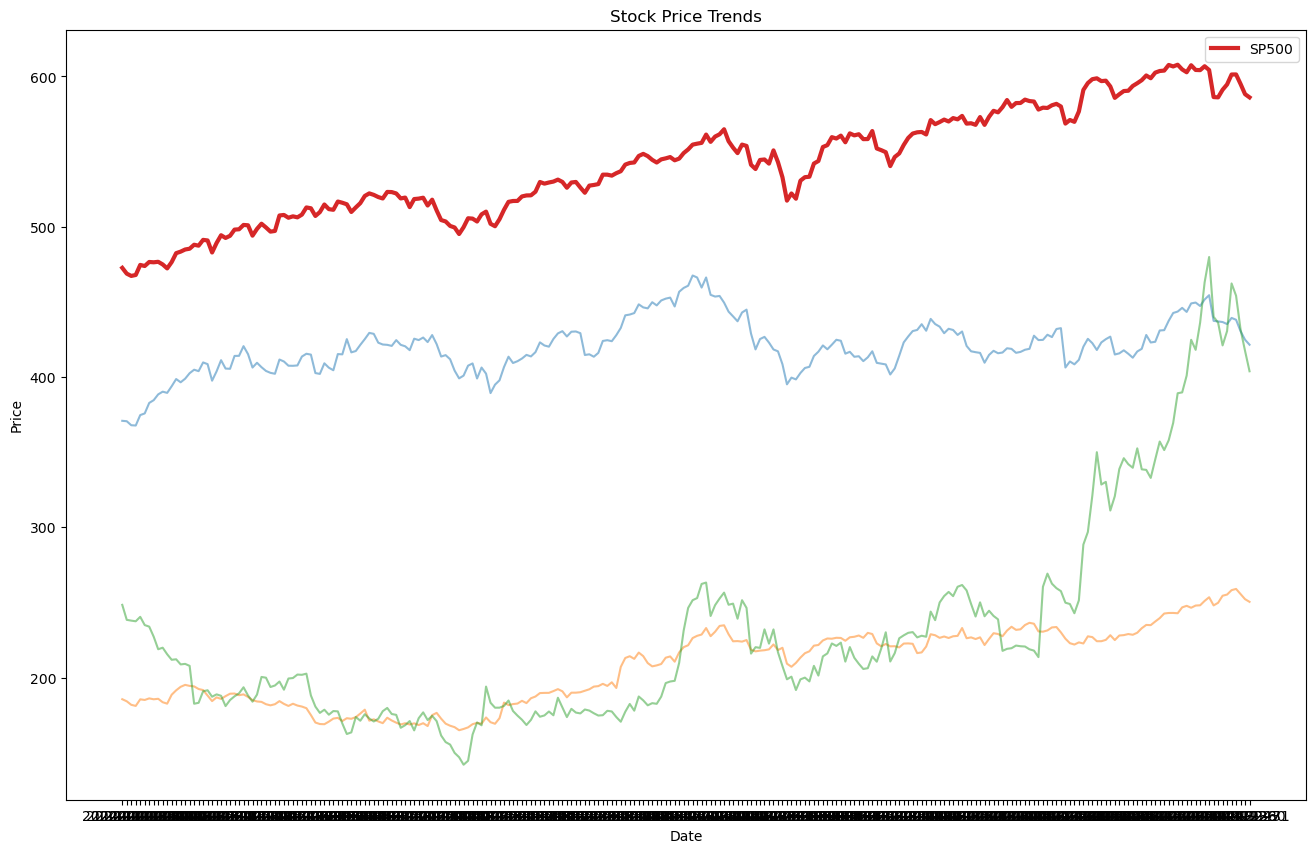

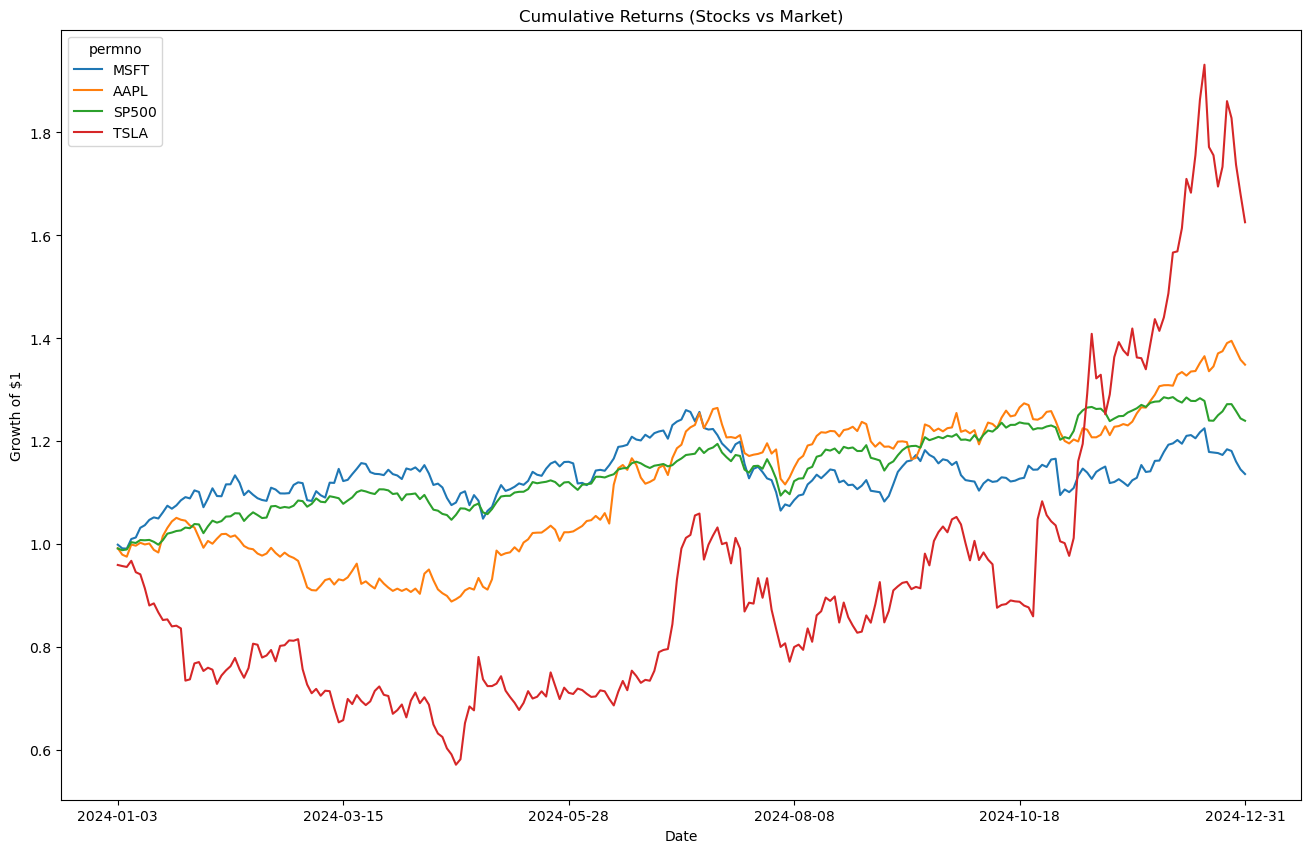


Daily Return (first few rows):
permno          MSFT      AAPL     SP500      TSLA
date                                              
2024-01-03 -0.000728 -0.007488 -0.008167 -0.040134
2024-01-04 -0.007178   -0.0127 -0.003221 -0.002181
2024-01-05 -0.000516 -0.004013   0.00137 -0.001849
2024-01-08  0.018872  0.024175  0.014276  0.012464
2024-01-09  0.002936 -0.002263 -0.001517 -0.022832


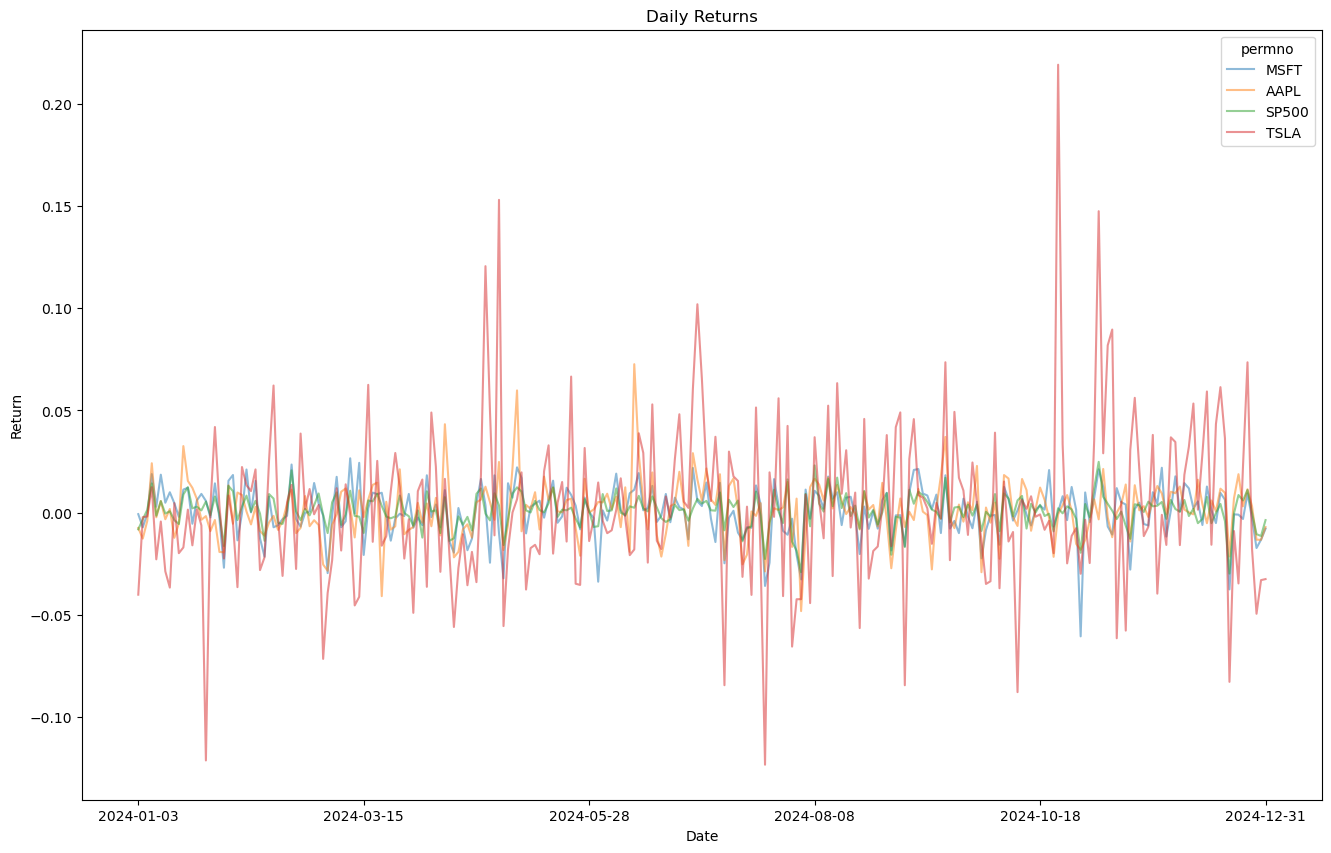


Average Return:
permno
TSLA     0.002721
AAPL     0.001292
SP500    0.000889
MSFT     0.000589
dtype: Float64


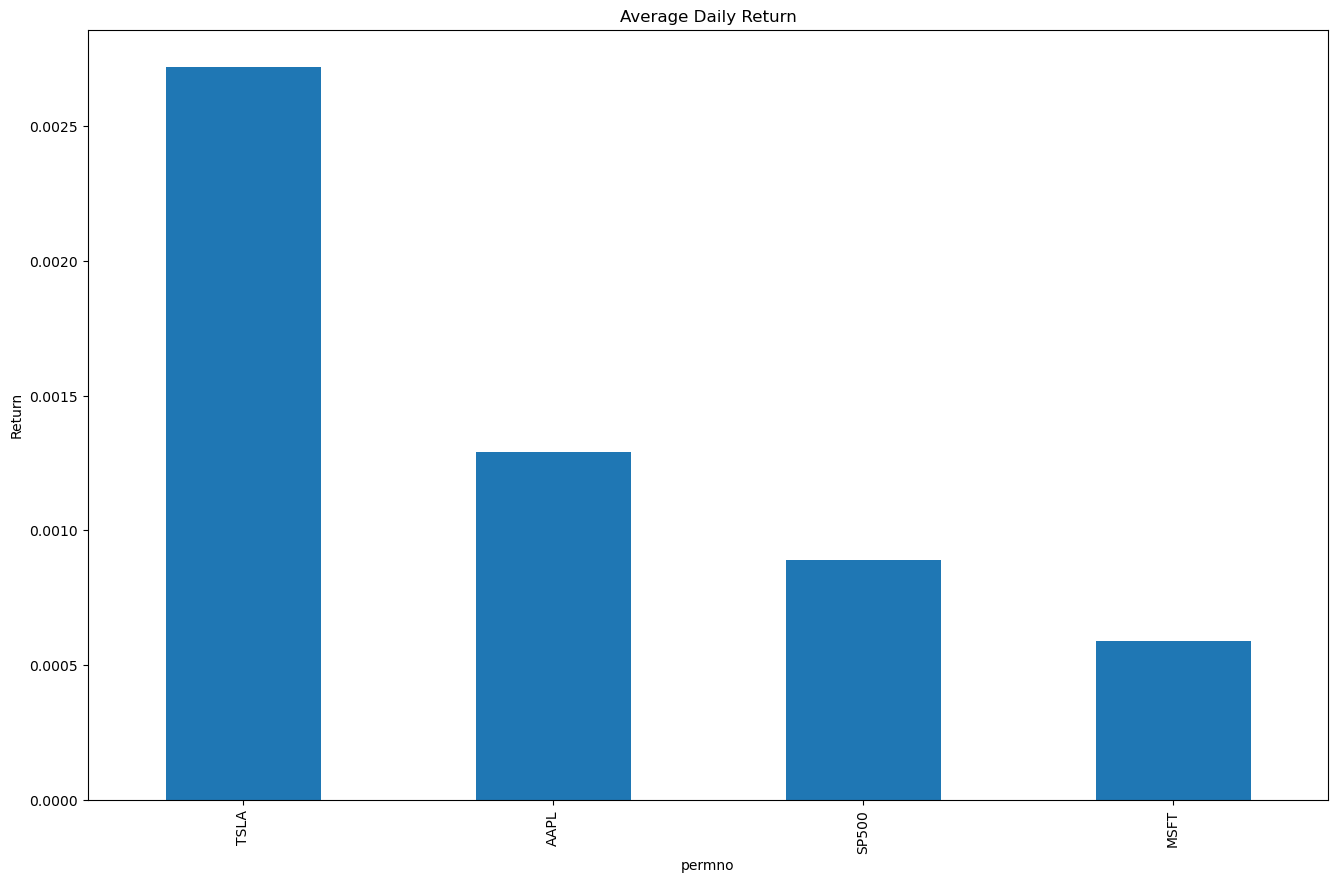


Volatility:
permno
TSLA     0.040078
AAPL     0.014125
MSFT     0.012551
SP500    0.007934
dtype: Float64


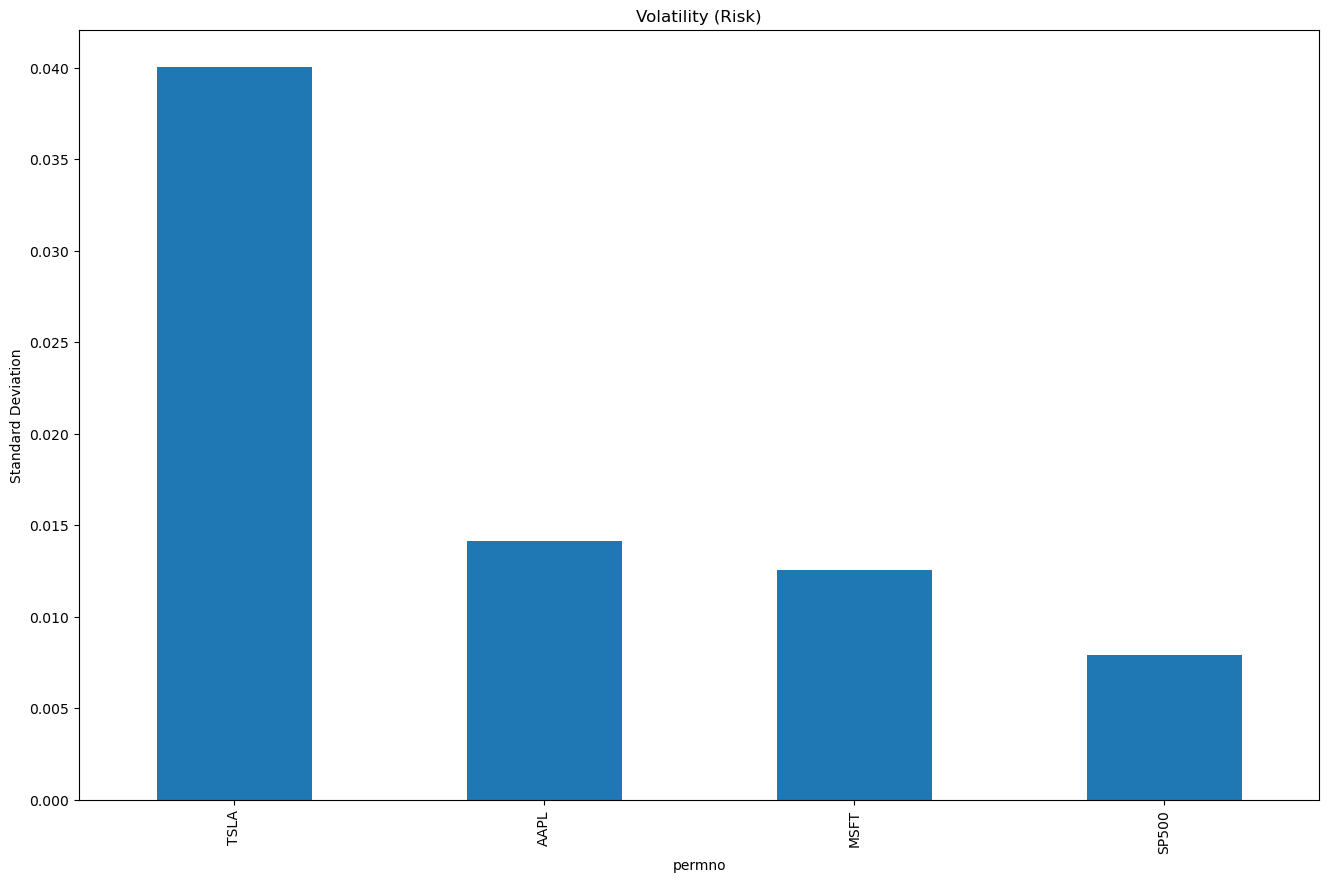


Sharpe Ratio:
permno
SP500    0.112021
AAPL     0.091475
TSLA     0.067885
MSFT     0.046928
dtype: Float64


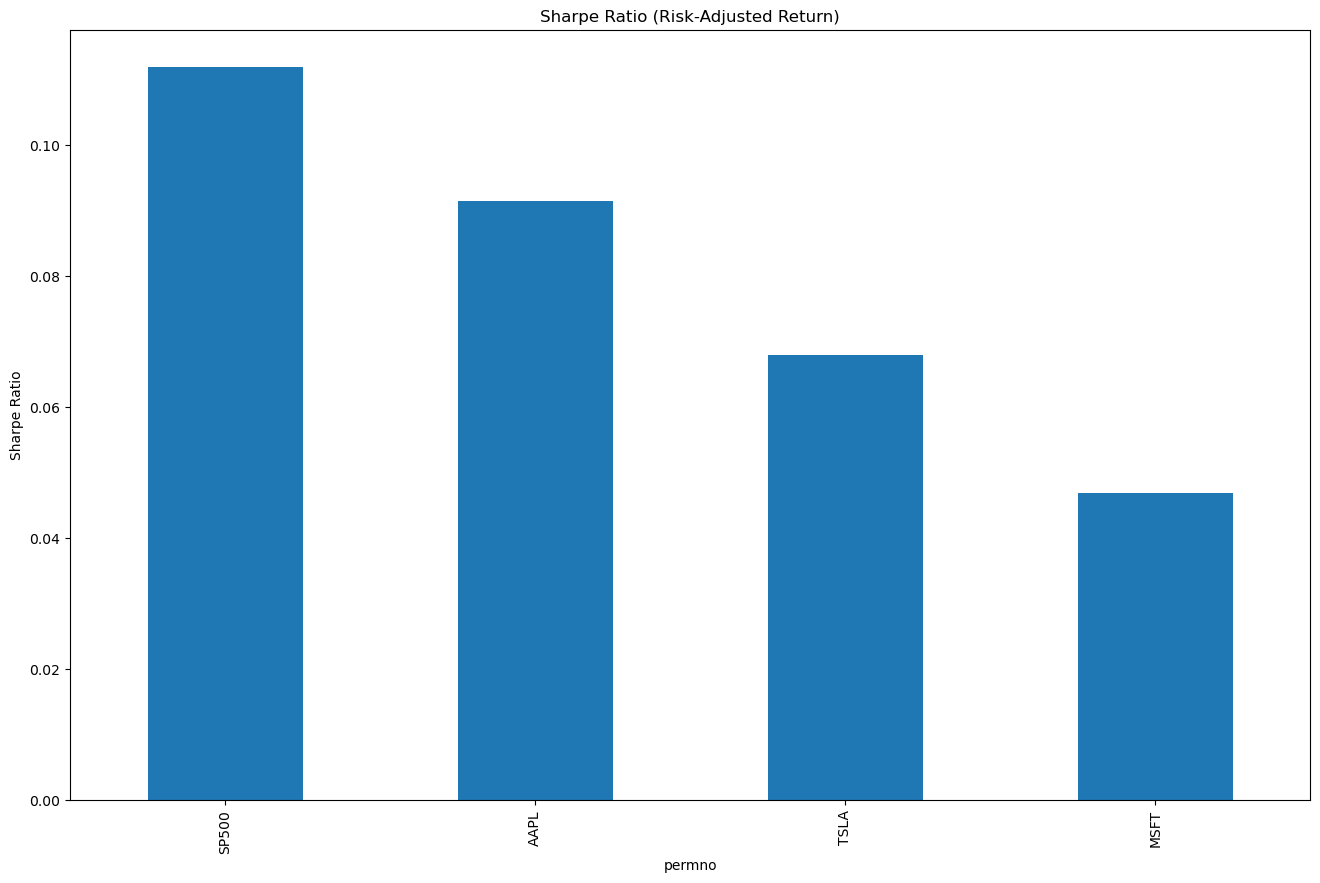

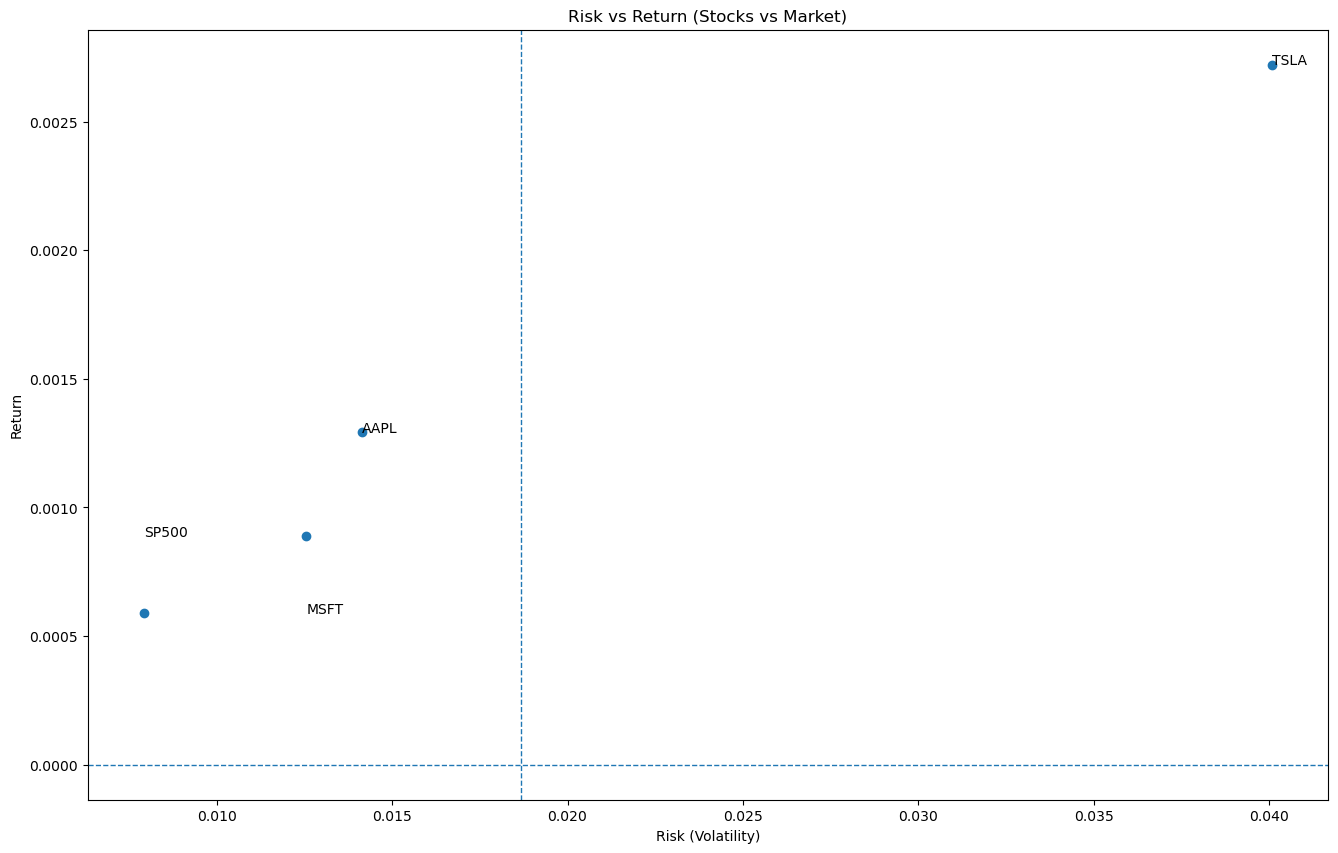


Stock Ranking:
          Return      Risk    Sharpe
permno                              
SP500   0.000889  0.007934  0.112021
AAPL    0.001292  0.014125  0.091475
TSLA    0.002721  0.040078  0.067885
MSFT    0.000589  0.012551  0.046928


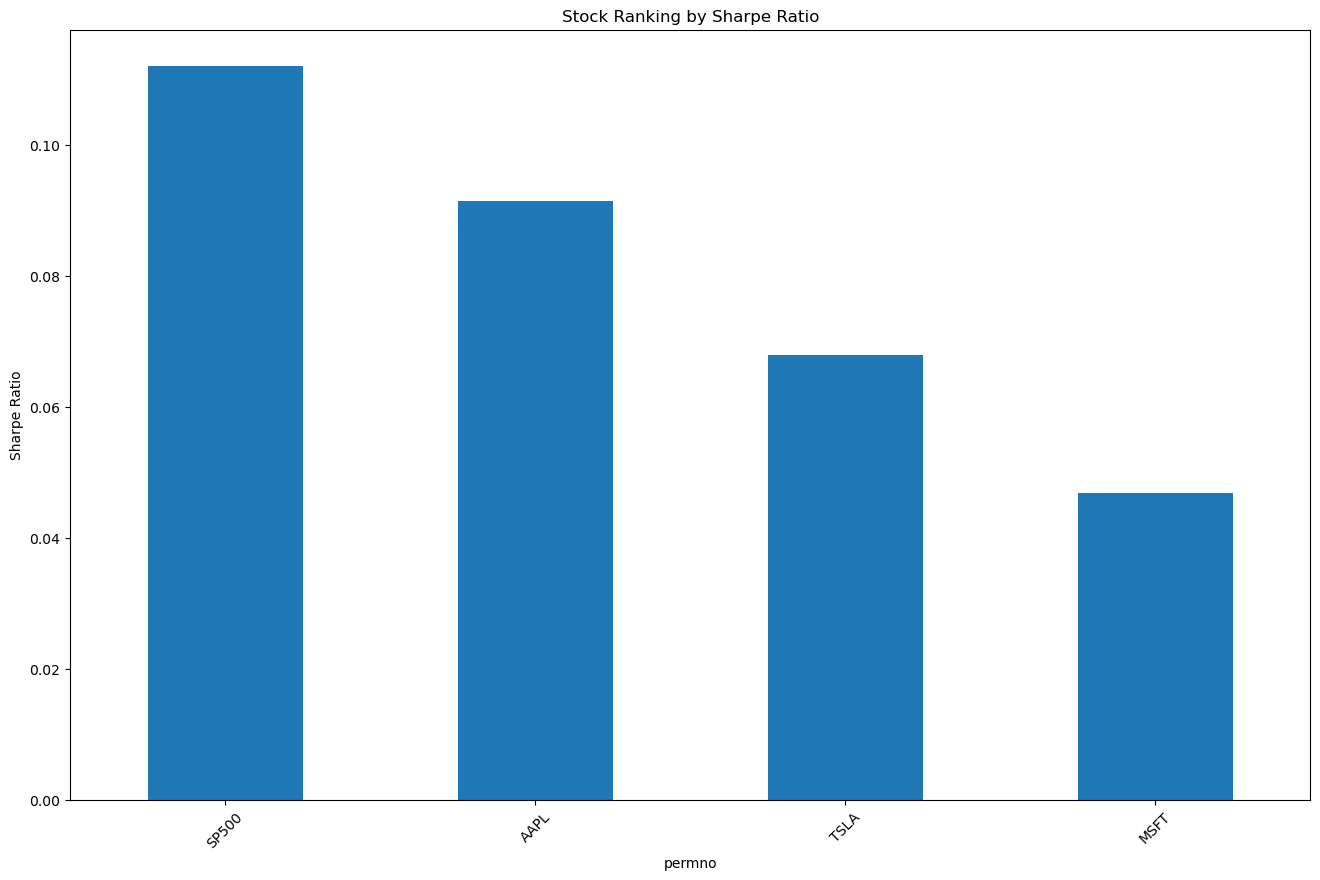


Final Summary:
          Return      Risk    Sharpe
permno                              
SP500   0.000889  0.007934  0.112021
AAPL    0.001292  0.014125  0.091475
TSLA    0.002721  0.040078  0.067885
MSFT    0.000589  0.012551  0.046928


In [13]:
db=run_analysis(
    tickers=['AAPL', 'TSLA', 'MSFT'],
    benchmark=84398,
    start_date='2024-01-01',
    end_date='2024-12-31',
    username='your_wrds_username'
)

We then apply the same analysis to the full set of selected companies.


Data Shape:

Missing Values:
permno
MSFT     0
NVDA     0
AMD      0
INTC     0
AAPL     0
NFLX     0
SP500    0
AMZN     0
GOOGL    0
META     0
TSLA     0
dtype: int64


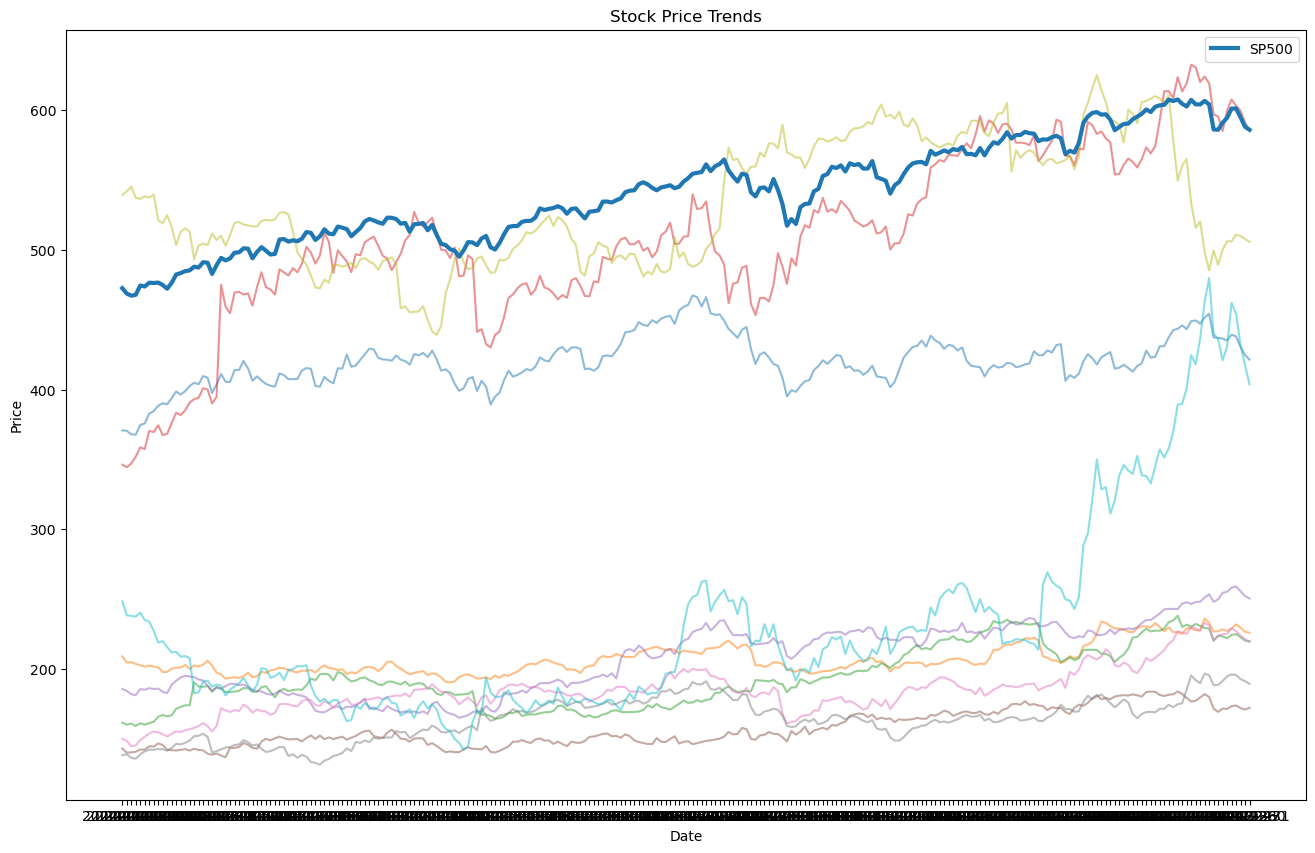

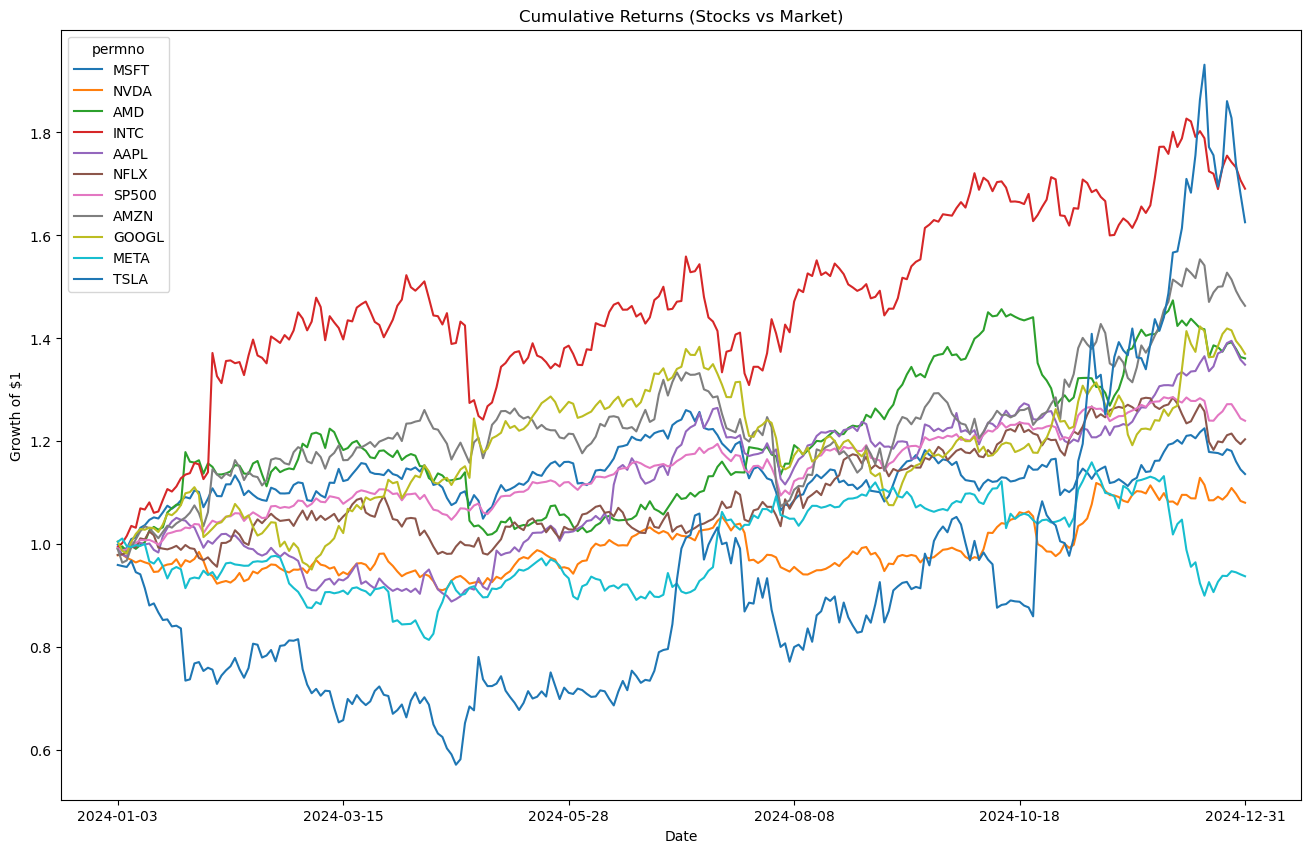


Daily Return (first few rows):
permno          MSFT      NVDA       AMD      INTC      AAPL      NFLX  \
date                                                                     
2024-01-03 -0.000728 -0.021388 -0.008669 -0.005256 -0.007488 -0.020555   
2024-01-04 -0.007178  0.001809  0.004747  0.007693   -0.0127  0.001213   
2024-01-05 -0.000516 -0.006686 -0.010568  0.013915 -0.004013  0.002781   
2024-01-08  0.018872 -0.004275   0.01244  0.019065  0.024175  0.011731   
2024-01-09  0.002936 -0.005082 -0.006578 -0.003429 -0.002263 -0.001054   

permno         SP500      AMZN     GOOGL      META      TSLA  
date                                                          
2024-01-03 -0.008167 -0.009738  0.005428  0.004988 -0.040134  
2024-01-04 -0.003221 -0.026268 -0.018212  0.006254 -0.002181  
2024-01-05   0.00137  0.004634 -0.004839 -0.014741 -0.001849  
2024-01-08  0.014276  0.026577  0.022913   -0.0016  0.012464  
2024-01-09 -0.001517  0.015225  0.015197  0.003448 -0.022832  


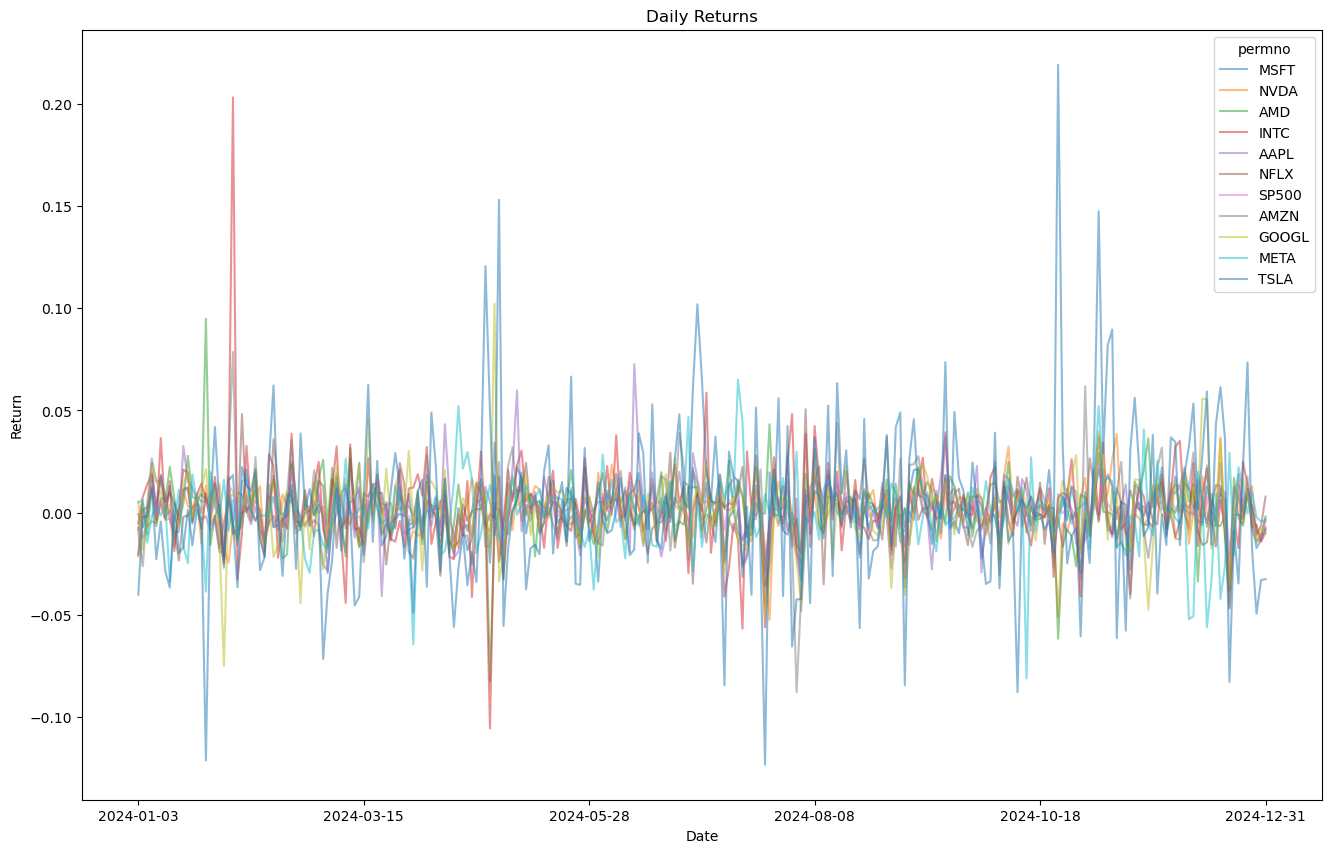


Average Return:
permno
TSLA     0.002721
INTC      0.00235
AMZN     0.001674
GOOGL    0.001411
AMD      0.001338
AAPL     0.001292
SP500    0.000889
NFLX     0.000831
MSFT     0.000589
NVDA     0.000374
META    -0.000108
dtype: Float64


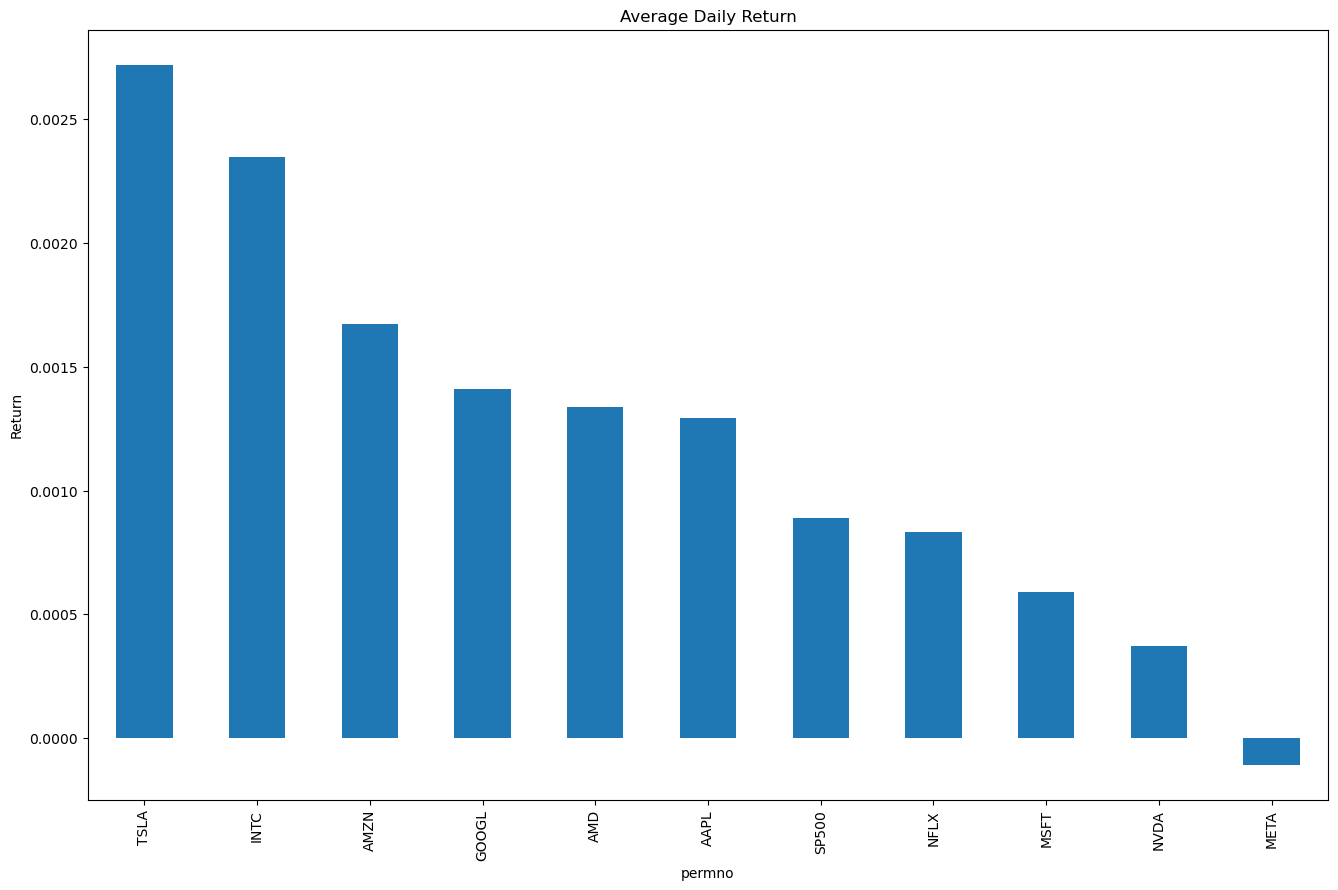


Volatility:
permno
TSLA     0.040078
INTC     0.022978
AMZN     0.017706
GOOGL    0.017691
META     0.017164
AMD      0.014802
AAPL     0.014125
NFLX     0.013505
MSFT     0.012551
NVDA     0.011317
SP500    0.007934
dtype: Float64


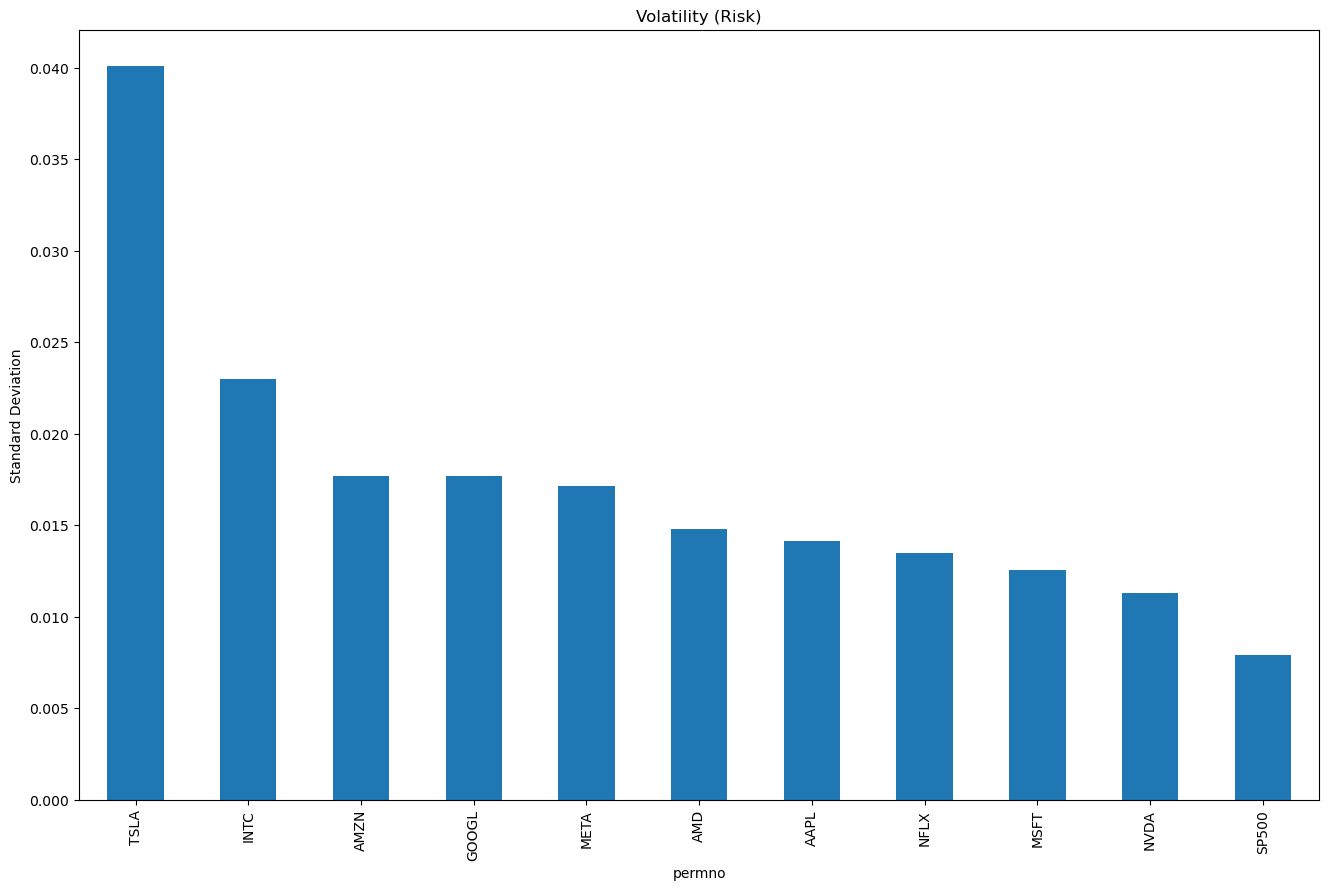


Sharpe Ratio:
permno
SP500    0.112021
INTC     0.102266
AMZN     0.094545
AAPL     0.091475
AMD      0.090416
GOOGL    0.079735
TSLA     0.067885
NFLX     0.061516
MSFT     0.046928
NVDA     0.033013
META    -0.006267
dtype: Float64


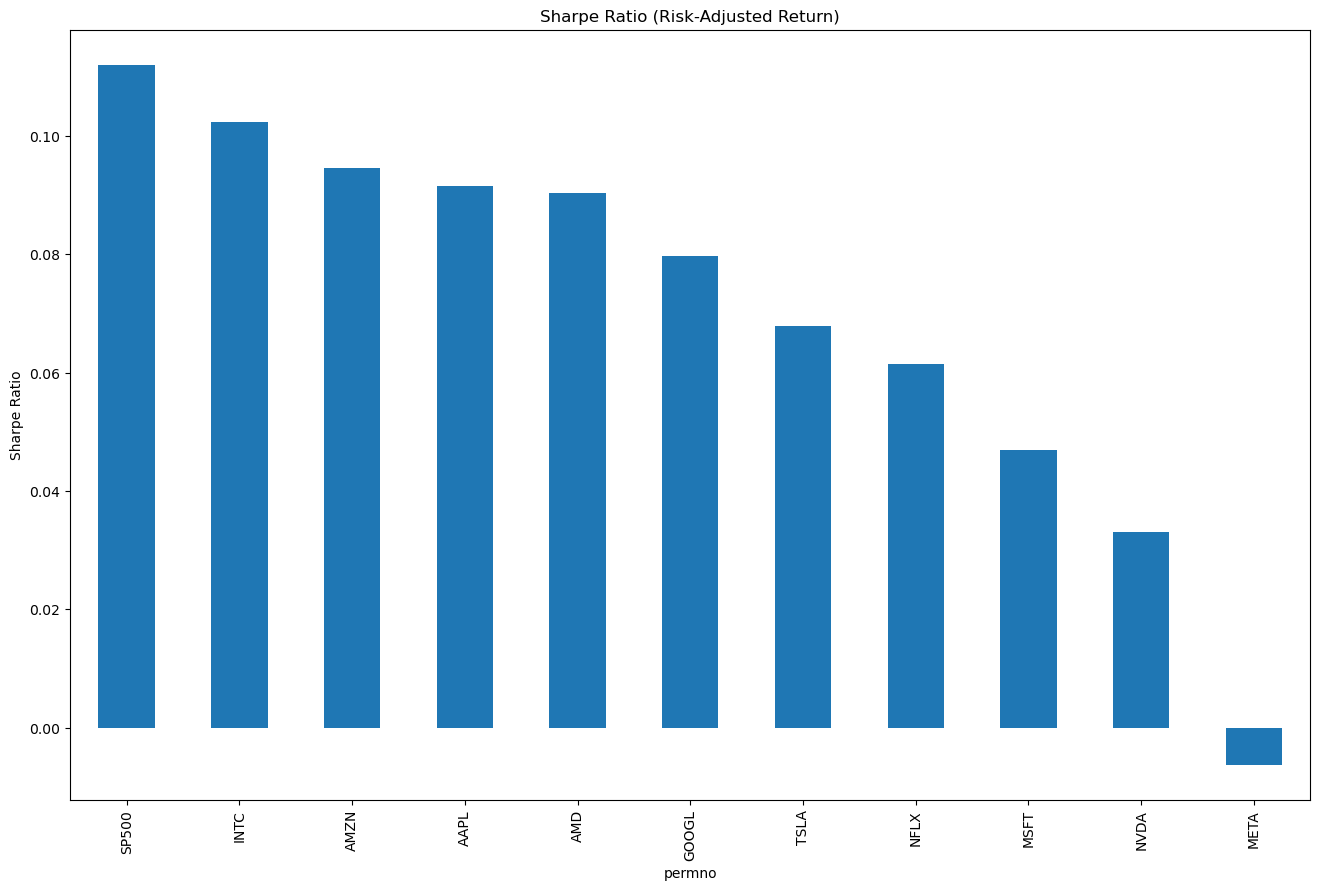

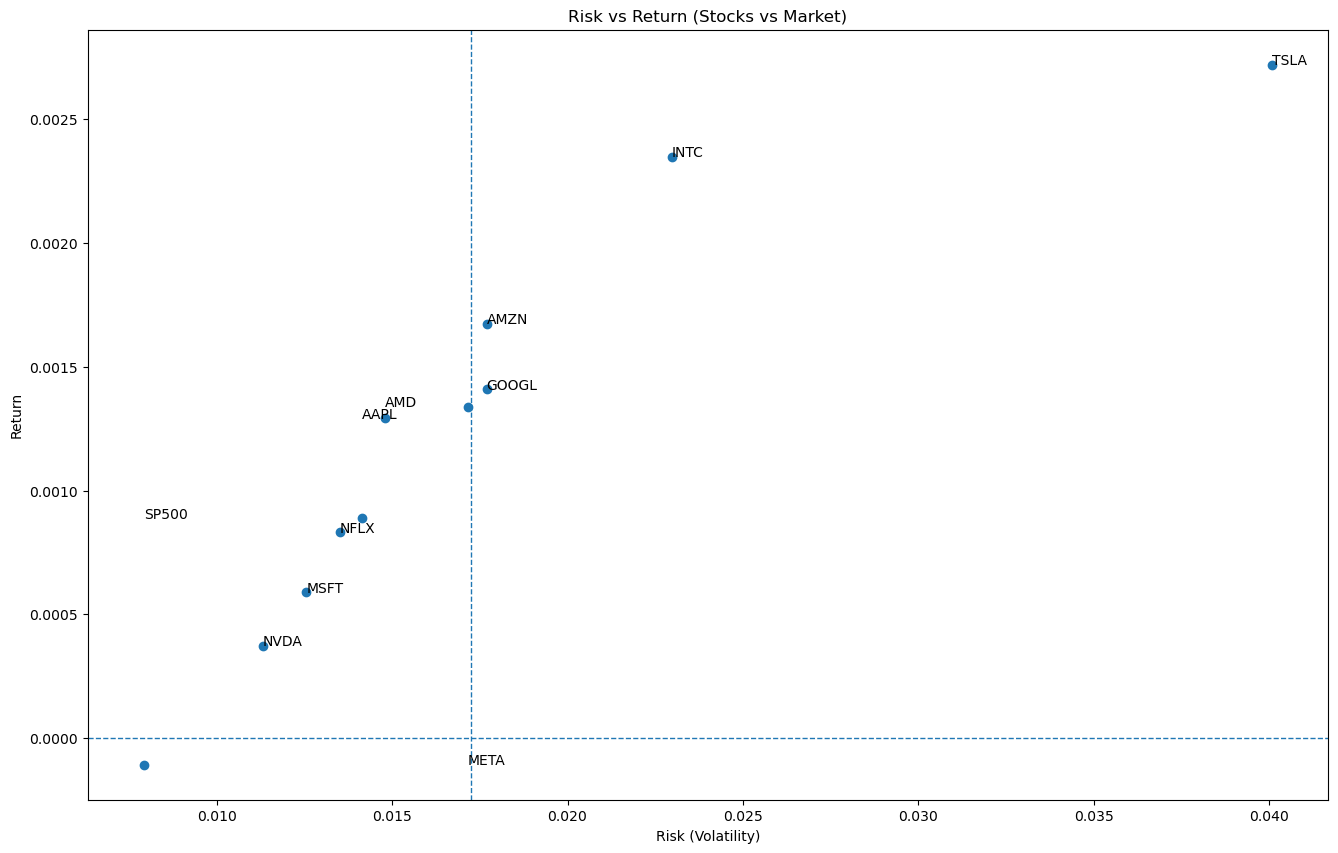


Stock Ranking:
          Return      Risk    Sharpe
permno                              
SP500   0.000889  0.007934  0.112021
INTC     0.00235  0.022978  0.102266
AMZN    0.001674  0.017706  0.094545
AAPL    0.001292  0.014125  0.091475
AMD     0.001338  0.014802  0.090416
GOOGL   0.001411  0.017691  0.079735
TSLA    0.002721  0.040078  0.067885
NFLX    0.000831  0.013505  0.061516
MSFT    0.000589  0.012551  0.046928
NVDA    0.000374  0.011317  0.033013
META   -0.000108  0.017164 -0.006267


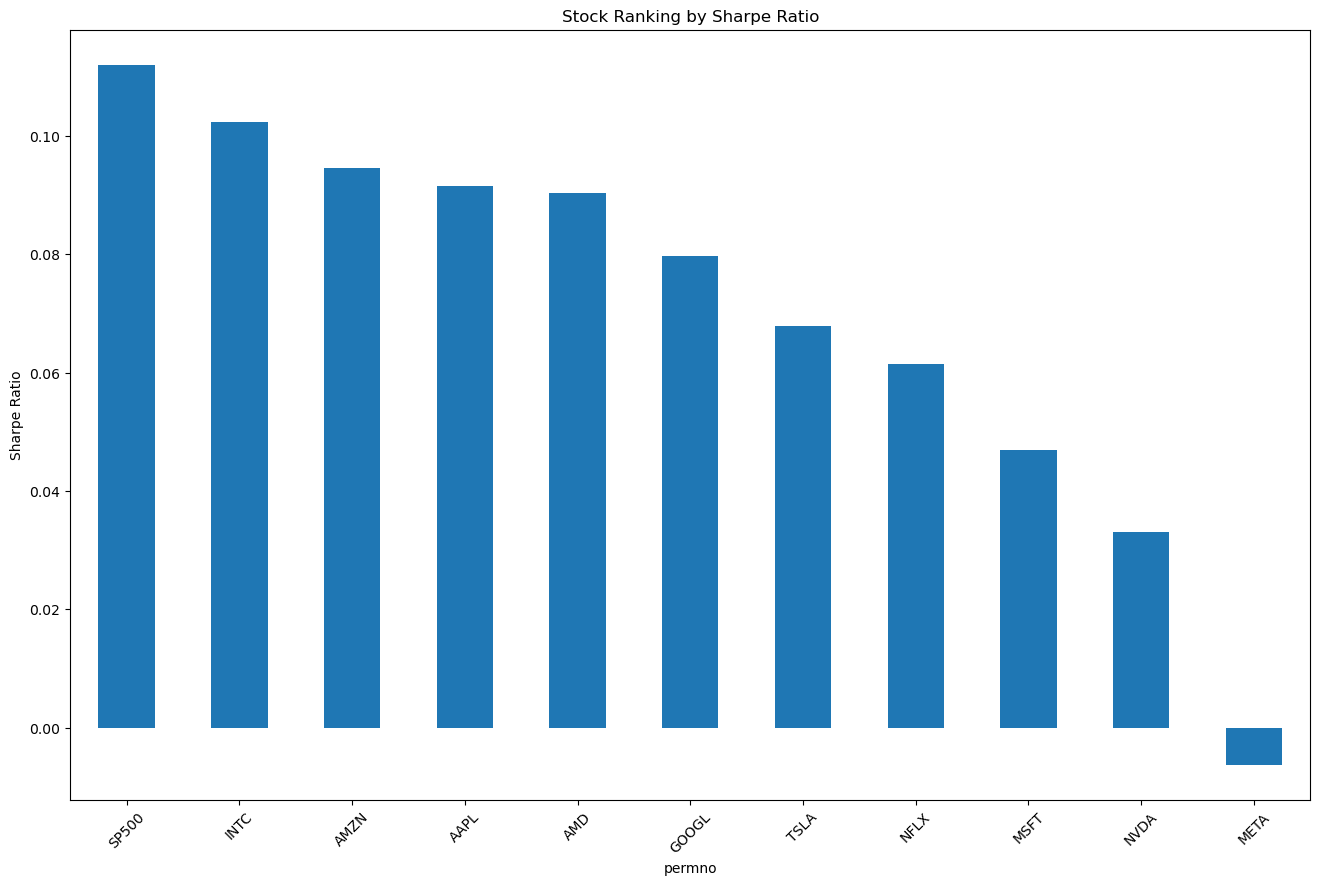


Final Summary:
          Return      Risk    Sharpe
permno                              
SP500   0.000889  0.007934  0.112021
INTC     0.00235  0.022978  0.102266
AMZN    0.001674  0.017706  0.094545
AAPL    0.001292  0.014125  0.091475
AMD     0.001338  0.014802  0.090416
GOOGL   0.001411  0.017691  0.079735
TSLA    0.002721  0.040078  0.067885
NFLX    0.000831  0.013505  0.061516
MSFT    0.000589  0.012551  0.046928
NVDA    0.000374  0.011317  0.033013
META   -0.000108  0.017164 -0.006267


In [14]:
run_analysis(
    tickers=['AAPL', 'MSFT', 'NVDA', 'TSLA', 'AMZN', 'GOOGL', 'META', 'NFLX', 'AMD', 'INTC'],
    benchmark=84398,
    start_date='2024-01-01',
    end_date='2024-12-31',
    username='your_wrds_username',
    db=db
)

## Analysis
We analyze stock performance based on return and risk.

### Price Trend

The price trend chart compares the price movements of individual stocks with the S&P 500 benchmark over time. It provides a visual understanding of how each stock evolves relative to the overall market.

From the chart, we observe clear differences across stocks. TSLA shows significant fluctuations and a strong upward movement towards the end of the period, indicating high growth potential but also instability. In contrast, MSFT follows a smoother and more stable trend, closely tracking the overall market. AAPL demonstrates moderate growth with occasional fluctuations.


Overall, the S&P 500 shows relatively smoother and more stable growth, serving as a useful benchmark for comparison.

### Cumulative Return

Cumulative return measures the total growth of an investment over time, assuming returns are reinvested. It allows us to evaluate long-term performance across different assets.

From the chart, TSLA achieves the highest cumulative return, significantly outperforming both other stocks and the S&P 500. However, its path is highly volatile. AAPL and MSFT display more stable and consistent growth, with returns closer to the benchmark. The S&P 500 shows steady upward growth with fewer fluctuations.

This indicates that although certain stocks may outperform the market, their performance may also be less stable. In contrast, the S&P 500 tends to provide more consistent growth.


### Daily Return
Daily return represents the percentage change in stock prices from one day to the next, capturing short-term price movements.

The chart shows that most returns fluctuate around zero, but TSLA exhibits more frequent and larger spikes compared to other stocks. AAPL and MSFT show relatively smaller fluctuations, while the S&P 500 remains the most stable.

This suggests that individual stocks, especially TSLA, are more volatile in the short run, whereas the market index benefits from diversification and exhibits lower short-term risk.

### Average Return

Average return measures the mean daily return of each stock over the selected period, indicating overall performance.

From the chart, TSLA has the highest average return, followed by AAPL, while MSFT and the S&P 500 show relatively lower values. The differences between stocks are noticeable but not extremely large.

This implies that while some individual stocks can outperform, the market benchmark provides relatively stable average performance.


### Volatility (Risk)

Volatility, measured by the standard deviation of returns, represents the level of risk associated with each stock.

The chart indicates that TSLA has the highest volatility, reflecting large price fluctuations. AAPL and MSFT have moderate levels of volatility, while the S&P 500 shows the lowest volatility among all.

This suggests that higher potential returns are associated with higher risk, while the market index offers more stable performance due to diversification.

## Sharpe Ratio

The Sharpe ratio measures risk-adjusted return by comparing return relative to volatility. It indicates how much return is generated per unit of risk.

From the chart, the S&P 500 and AAPL show relatively strong Sharpe ratios, indicating efficient risk-return trade-offs. Although TSLA has high returns, its Sharpe ratio is lower due to high volatility.

This demonstrates that the highest return does not necessarily correspond to the best performance when risk is taken into account.

### Risk vs Return

This chart shows the relationship between risk (volatility) and return for each stock.

From the chart, TSLA is positioned in the high-risk, high-return region. AAPL lies in a moderate risk-return zone, while MSFT and the S&P 500 are located in lower-risk areas with more stable returns.

This suggests that although higher risk is generally associated with higher returns, the relationship is not perfectly consistent across all stocks.

### Stock Ranking

Stocks are ranked based on their Sharpe ratios, which incorporate both return and risk.

From the ranking, we can identify which stocks provide the best risk-adjusted performance. Stocks with higher Sharpe ratios are considered more efficient, as they deliver higher returns for each unit of risk.

The S&P 500 typically ranks moderately, indicating that while it may not always achieve the highest returns, it offers a good balance between stability and performance.

## Conclusion

This analysis compares stock performance using multiple dimensions, including price trends, returns, risk, and risk-adjusted measures.

The results show that while individual stocks may outperform the market, they often come with higher volatility. In contrast, the S&P 500 provides more stable and consistent performance due to diversification.

Therefore, investors should consider both return and risk when making investment decisions, rather than focusing solely on performance.